# ROCC Retrieval Explainability

This notebook explains how the locked ROCC history selections affect retrieval on selected TopiOCQA development queries, tracing exact Shapley contributions from conversation turns through question–answer fields and tokens to IterCQR rewrites and BM25 reciprocal rank.

### Frozen explanation protocol

The code labels `TURN`, `Q/A`, and `TOKEN` correspond to thesis granularities V1, V2, and V3. Their players are complete turns $T_i=(q_i,a_i)$, query or answer fields $q_i$ and $a_i$, and individual words, respectively. Every coalition passes through the same B64 serializer, frozen IterCQR rewriter, and BM25 retriever. TOKEN players preserve the wording of the selected history $\widehat H_t$, so its selected-word coalition reproduces $R_{64}$. The baseline comparison in this notebook is $I_{64}$, not $I_{512}$.

In [1]:
from __future__ import annotations

import gc
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import re
import sys
import time
from collections import OrderedDict
from pathlib import Path
from typing import Any, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
from IPython.display import Image as DisplayImage, display
from PIL import Image
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, DrawingArea, HPacker, TextArea
from matplotlib.patches import Rectangle


def resolve_project_root(start: Path) -> Path:
    configured = os.environ.get("ROCC_ROOT") or os.environ.get("MASTER_THESIS_PROJECT_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if not (candidate / "experiments" / "rocc").is_dir():
            raise FileNotFoundError(f"Configured ROCC checkout is missing: {candidate}")
        return candidate
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "rocc").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Open this notebook from your ROCC checkout, or set ROCC_ROOT to it. "
        "In Colab, first clone the public repository over HTTPS or authenticate "
        "your own private checkout; no private clone or deploy key is assumed."
    )


PROJECT_ROOT = resolve_project_root(Path.cwd())
os.environ["MASTER_THESIS_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Pyserini 2.0/Lucene 10 requires Java 21.  Configure the notebook process
# before the public ROCC package (and therefore Pyjnius) can be imported.
# Set JAVA_HOME for your Java 21 installation; Linux installations are discovered too.
java_candidates = ([Path(os.environ["JAVA_HOME"])] if os.environ.get("JAVA_HOME") else [])
java_candidates += sorted(Path("/usr/lib/jvm").glob("*21*"))
JAVA21_HOME = next((p for p in java_candidates if any(
    (p / relative).is_file() for relative in ("lib/server/libjvm.so", "lib/server/libjvm.dylib", "bin/server/jvm.dll")
)), None)
if JAVA21_HOME is None:
    raise FileNotFoundError("Install Java 21 and set JAVA_HOME to its installation directory.")
JAVA21_JVM = next(p for p in (
    JAVA21_HOME / "lib/server/libjvm.so", JAVA21_HOME / "lib/server/libjvm.dylib", JAVA21_HOME / "bin/server/jvm.dll"
) if p.is_file())
os.environ["JAVA_HOME"] = str(JAVA21_HOME)
os.environ["JVM_PATH"] = str(JAVA21_JVM)
os.environ["PATH"] = str(JAVA21_HOME / "bin") + os.pathsep + os.environ.get("PATH", "")

from experiments import rocc


PROTOCOL = "nb09_exact_hierarchical_shap"
EXPECTED_SHAP_VERSION = "0.52.0"
BUDGET = 64
EXACT_BATCH_SIZE = 128
MAX_EXACT_PLAYERS = 14
BM25_K1 = 0.9
BM25_B = 0.4

RESULT_DIR = PROJECT_ROOT / "experiments/results/09_explainability"
GAME_DIR = RESULT_DIR / "games"
FIGURE_DIR = RESULT_DIR / "figures"
for directory in (RESULT_DIR, GAME_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DATA_DIR = PROJECT_ROOT / "experiments/data/topiocqa"
MODEL_DIR = PROJECT_ROOT / "experiments/model/IterCQR/IterCQR Model"
# Execution requires the complete TopiOCQA BM25 index, even with saved games.
# The input check stops if segments_1 is missing; later BM25 term weights
# require the full index. Saved notebook outputs can be viewed without rerunning.
BM25_INDEX_DIR = (
    PROJECT_ROOT / "experiments/data/pyserini_bm25_lucene_topiocqa/lucene_index"
)
VITERBI_PATH = (
    PROJECT_ROOT
    / "experiments/results/07a_topiocqa_final/predictions/pretrained/viterbi.jsonl"
)
TEACHER_PATH = (
    PROJECT_ROOT
    / "experiments/results/04_teacher/rocc_history_labels_topiocqa_dev.jsonl"
)

PLOT_SPECS = (
    ("dev55", "dev:55:4"),
    ("dev43", "dev:43:8"),
    ("dev203", "dev:203:8"),
    ("dev48", "dev:48:3"),
    ("dev20", "dev:20:4"),
    ("dev138", "dev:138:5"),
    ("dev105_turn7", "dev:105:7"),
    ("dev203_turn8", "dev:203:8"),
    ("dev68", "dev:68:3"),
    ("dev96", "dev:96:3"),
    ("dev134", "dev:134:2"),
)
SAMPLE_IDS = tuple(dict.fromkeys(sample_id for _, sample_id in PLOT_SPECS))

EXPECTED_INPUT_SHA256 = {
    "dev": "f551e9a4dfe08cbebb9cc68d4b9206b6df18d42c48a6dfc404b4883a53ebef4c",
    "model": "1a25ceaf597bf92ff2897cccb22e9c46b807efbf78a3234186066e1f62f16ae3",
    "model_config": "a1f20ac0527995010a72aa51a3c7dd1fec6bcb15c0d69bcbdca5611f035ee2fa",
    "tokenizer": "d60acb128cf7b7f2536e8f38a5b18a05535c9e14c7a355904270e15b0945ea86",
    "viterbi": "fdd273bfbd8355a23d9a638776414144449ad3e3574083cab0f9644905cd577c",
    "teacher": "43ced1a1f302672a29737d14fe02a1d9e6c751ea0eb1225aebe8222b72f49c37",
    "index_segments": "65484072fe550eec01e59fded01989d361385c00398dd754fd9a7f9de2e73751",
}

forced = os.environ.get("ROCC_NB09_FORCE_GAMES", "").strip()
FORCE_GAME_IDS = {item.strip() for item in forced.split(",") if item.strip()}
if FORCE_GAME_IDS - set(SAMPLE_IDS):
    raise ValueError(f"Unknown forced sample IDs: {sorted(FORCE_GAME_IDS - set(SAMPLE_IDS))}")

if shap.__version__ != EXPECTED_SHAP_VERSION:
    raise RuntimeError(
        f"Expected SHAP {EXPECTED_SHAP_VERSION}, found {shap.__version__}."
    )

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

### Semantic interpretation of ROCC selections

ROCC’s collapsed CRF identifies which history tokens should be retained, but it does not assign semantic roles such as `ENTITY`, `DEFINITION`, or `RELATION_CUE`. The post-hoc annotations make the selected evidence interpretable by mapping every retained token to one of the original Teacher categories.

These labels are explanatory overlays. They do not change the ROCC selection, IterCQR rewrite, SHAP values, document ranking, or reciprocal rank. Their purpose is to expose which semantic information ROCC preserves and how that evidence can support retrieval.

In [2]:
POSTHOC_ANNOTATIONS = {
    "dev:20:4": [
        {"turn": 1, "field": "Q", "start": 2, "end": 4, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 1, "field": "A", "start": 2, "end": 5, "label": "DEFINITION", "basis": "teacher_overlap"},
    ],
    "dev:43:8": [
        {"turn": 4, "field": "Q", "start": 0, "end": 4, "label": "RELATION_CUE", "basis": "analyst", "alternative": "KEY_TERM for director"},
        {"turn": 4, "field": "A", "start": 0, "end": 2, "label": "ENTITY", "basis": "teacher_exact"},
    ],
    "dev:48:3": [
        {"turn": 1, "field": "Q", "start": 2, "end": 4, "label": "ENTITY", "basis": "teacher_overlap"},
        {"turn": 1, "field": "A", "start": 2, "end": 5, "label": "DEFINITION", "basis": "teacher_exact"},
    ],
    "dev:55:4": [
        {"turn": 2, "field": "A", "start": 0, "end": 2, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 3, "field": "A", "start": 0, "end": 6, "label": "DEFINITION", "basis": "teacher_overlap"},
    ],
    "dev:68:3": [
        {"turn": 1, "field": "Q", "start": 2, "end": 3, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 1, "field": "A", "start": 0, "end": 2, "label": "DEFINITION", "basis": "teacher_exact", "alternative": "ENTITY"},
    ],
    "dev:96:3": [
        {"turn": 1, "field": "Q", "start": 3, "end": 6, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 2, "field": "Q", "start": 1, "end": 4, "label": "RELATION_CUE", "basis": "teacher_overlap"},
    ],
    "dev:105:7": [
        {"turn": 1, "field": "A", "start": 0, "end": 2, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 6, "field": "Q", "start": 2, "end": 5, "label": "RELATION_CUE", "basis": "teacher_exact"},
        {"turn": 6, "field": "A", "start": 0, "end": 4, "label": "DEFINITION", "basis": "teacher_overlap"},
    ],
    "dev:134:2": [
        {"turn": 1, "field": "Q", "start": 1, "end": 2, "label": "RELATION_CUE", "basis": "analyst"},
        {"turn": 1, "field": "Q", "start": 2, "end": 4, "label": "KEY_TERM", "basis": "analyst", "alternative": "CONCEPT"},
        {"turn": 1, "field": "Q", "start": 5, "end": 8, "label": "ENTITY", "basis": "analyst"},
        {"turn": 1, "field": "A", "start": 0, "end": 2, "label": "ENTITY", "basis": "analyst", "note": "Entity label does not distinguish the character from an actor or director."},
    ],
    "dev:138:5": [
        {"turn": 1, "field": "Q", "start": 2, "end": 5, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 1, "field": "A", "start": 2, "end": 5, "label": "DEFINITION", "basis": "teacher_exact"},
    ],
    "dev:203:8": [
        {"turn": 4, "field": "A", "start": 0, "end": 6, "label": "ENTITY", "basis": "teacher_exact"},
        {"turn": 5, "field": "A", "start": 0, "end": 7, "label": "DEFINITION", "basis": "teacher_exact", "alternative": "ENTITY for Geneva, Switzerland"},
    ],
}

LABELS = {"ENTITY", "CONCEPT", "KEY_TERM", "DEFINITION", "RELATION_CUE"}
assert set(POSTHOC_ANNOTATIONS) == set(SAMPLE_IDS)
assert all(span["label"] in LABELS for spans in POSTHOC_ANNOTATIONS.values() for span in spans)

### Input integrity and cache identity

SHA-256 checks bind every explanation to the frozen data, model, tokenizer, ROCC selections, Teacher labels, and Lucene index generation. Their combined fingerprint identifies the reusable cache and prevents results from different inputs from being mixed.

All ten samples must match their TopiOCQA conversation, evaluation row, and ROCC selection. Teacher labels cover nine samples.

In [3]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(1024 * 1024):
            digest.update(chunk)
    return digest.hexdigest()


resources = rocc.resolve_topiocqa_resources(DATA_DIR)
rocc.validate_itercqr_checkpoint(MODEL_DIR)
required_paths = {
    "dev": resources.dev_json,
    "model": MODEL_DIR / "pytorch_model.bin",
    "model_config": MODEL_DIR / "config.json",
    "tokenizer": MODEL_DIR / "spiece.model",
    "viterbi": VITERBI_PATH,
    "teacher": TEACHER_PATH,
    "index_segments": BM25_INDEX_DIR / "segments_1",
}
for name, path in required_paths.items():
    if not path.is_file():
        raise FileNotFoundError(path)
# Keep public dataset, IterCQR model/config/tokenizer identities frozen. Only
# newly generated selector/teacher/index file identities may use local lineage.
from experiments.rocc.paths import bind_notebook_lineage
EXPECTED_INPUT_SHA256 = bind_notebook_lineage(
    RESULT_DIR, "nb09", EXPECTED_INPUT_SHA256,
    {name: required_paths[name] for name in ("viterbi", "teacher", "index_segments")},
    manifest_fields=(
        ("viterbi", VITERBI_PATH.parent / "manifest.json", ("files", "viterbi", "sha256")),
        ("teacher", TEACHER_PATH.with_suffix(".manifest.json"), ("dataset_sha256",)),
    ),
)
observed_hashes = {name: sha256_file(path) for name, path in required_paths.items()}
if observed_hashes != EXPECTED_INPUT_SHA256:
    drift = {
        key: {"expected": EXPECTED_INPUT_SHA256[key], "observed": observed_hashes[key]}
        for key in EXPECTED_INPUT_SHA256
        if observed_hashes[key] != EXPECTED_INPUT_SHA256[key]
    }
    raise RuntimeError(f"Frozen NB09 inputs drifted: {drift}")

input_fingerprint = hashlib.sha256(
    json.dumps(observed_hashes, sort_keys=True).encode("utf-8")
).hexdigest()
CACHE_DB = (
    PROJECT_ROOT
    / ".cache/master_thesis/09_explainability"
    / f"runtime_{input_fingerprint[:16]}.sqlite3"
)

dev_frame = rocc.add_conversation_columns(
    rocc.load_topiocqa_frame(resources, splits=("dev",))
)
sample_by_id = {
    sample.sample_id: sample
    for sample in rocc.build_topiocqa_conversation_samples(
        dev_frame, minimum_history_depth=1, progress=False
    )
    if sample.sample_id in SAMPLE_IDS
}
row_by_id = {
    str(row.sample_id): row
    for row in dev_frame[dev_frame["sample_id"].isin(SAMPLE_IDS)].itertuples()
}
if set(sample_by_id) != set(SAMPLE_IDS) or set(row_by_id) != set(SAMPLE_IDS):
    raise RuntimeError("The frozen NB09 sample set is incomplete in TopiOCQA Dev.")

selected_history_by_id = rocc.read_selected_histories_jsonl(
    VITERBI_PATH, progress=False
)
teacher_by_sample = {
    str(row["sample_id"]): row
    for row in rocc.read_label_jsonl(TEACHER_PATH, progress=False)
    if str(row["sample_id"]) in SAMPLE_IDS
}

if not set(SAMPLE_IDS).issubset(selected_history_by_id):
    raise RuntimeError("ROCC selections are missing for frozen NB09 samples.")
assert set(SAMPLE_IDS) - set(teacher_by_sample) == {"dev:134:2"}

display(pd.DataFrame([{
    "protocol": PROTOCOL,
    "unique_samples": len(SAMPLE_IDS),
    "plot_pages": len(PLOT_SPECS),
    "device_if_recomputed": "cuda:0" if torch.cuda.is_available() else "cpu",
    "cache": str(CACHE_DB),
    "input_fingerprint": input_fingerprint,
}]))

,protocol,unique_samples,plot_pages,device_if_recomputed,cache,input_fingerprint
0,nb09_exact_hierarchical_shap,10,11,cuda:0,/.cache/master_thesis/09_explainabil...,60da0ae4d4556171bcd821ee9efdae1563e2cf5bf54d30...


### Exact hierarchical retrieval games

For each game, $\mathcal P$ is its player set and $S\subseteq\mathcal P$ is a coalition. The unchanged current query $q_t$ is combined with the retained history, then processed through the frozen B64 serializer, IterCQR rewriter, and BM25 retriever. Its reciprocal rank is the game value $v(S)$. The empty coalition $v(\varnothing)$ uses query-only rewriting.

The hierarchy selects the two strongest turns, then the two strongest fields within those turns, and includes all ROCC-selected fields in the word game. Each defined game is evaluated exactly, with at most 14 players. The complete turn and field games and restricted word game have different player sets.

#### Shapley values

For player $i$, each coalition without $i$ is compared with the same coalition containing $i$. The exact weighted mean is

$$
\phi_i=
\sum_{S\subseteq\mathcal P\setminus\{i\}}
\frac{|S|!(|\mathcal P|-|S|-1)!}{|\mathcal P|!}
\left[v(S\cup\{i\})-v(S)\right].
$$

The weights give equal importance to every possible player ordering. The contributions satisfy

$$
\sum_{i\in\mathcal P}\phi_i=v(\mathcal P)-v(\varnothing).
$$

The constructed example in the thesis appendix uses $q_t=$ “where was she born” and $\mathcal P=\{\text{Marie},\text{Curie}\}$. Its assumed coalition values are

| Coalition $S$ | $v(S)$ |
|---|---:|
| $\varnothing$ | 0 |
| $\{\text{Marie}\}$ | 0 |
| $\{\text{Curie}\}$ | 0 |
| $\{\text{Marie},\text{Curie}\}$ | 1 |

Both words receive half of the joint gain

$$
\phi_{\text{Marie}}=\phi_{\text{Curie}}=\tfrac12[(0-0)+(1-0)]=\tfrac12.
$$

These are constructed values, not measured ROCC results. A negative Shapley value means that a player reduces reciprocal rank on average across coalitions. It does not imply that deleting it from the complete selection will improve retrieval.

Every stored game contains all $2^{|\mathcal P|}$ coalitions and satisfies the additivity check. The complete history coalition in the turn and field games reproduces $I_{64}$. The ROCC-selected word coalition reproduces $R_{64}$; coarser projections can yield different results.

In [4]:
def history_rows(turns: Sequence[tuple[str, str]]) -> list[dict[str, str]]:
    return [
        {"question": str(question), "answer": str(answer)}
        for question, answer in turns
        if question or answer
    ]


def coalition_history(mask: Sequence[bool], players: Sequence[tuple]) -> list[dict[str, str]]:
    turns: dict[int, list[list[str]]] = {}
    for keep, (_, turn, field, text, *_) in zip(mask, players, strict=True):
        if keep:
            turns.setdefault(int(turn), [[], []])[int(field)].append(str(text))
    return history_rows([
        (" ".join(fields[0]), " ".join(fields[1]))
        for _, fields in sorted(turns.items())
    ])


def span_surfaces(source: str, span: str) -> dict[int, str]:
    clean = lambda word: re.sub(r"\W+", "", word).casefold()
    source_norm = [
        (index, clean(word))
        for index, word in enumerate(source.split())
        if clean(word)
    ]
    span_words = [word for word in span.split() if clean(word)]
    span_norm = [clean(word) for word in span_words]
    matches: list[list[int]] = []
    for start in range(len(source_norm) - len(span_norm) + 1):
        candidate = source_norm[start:start + len(span_norm)]
        if [word for _, word in candidate] == span_norm:
            matches.append([index for index, _ in candidate])
    if len(matches) > 1:
        raise ValueError(f"Ambiguous ROCC span {span!r} in {source!r}")
    if matches:
        positions = matches[0]
    else:
        positions, start = [], 0
        for wanted in span_norm:
            match = next(
                (
                    index
                    for index in range(start, len(source_norm))
                    if source_norm[index][1] == wanted
                ),
                None,
            )
            if match is None:
                break
            positions.append(source_norm[match][0])
            start = match + 1
    if len(positions) != len(span_words):
        raise ValueError(f"ROCC span not found: {span!r} in {source!r}")
    return dict(zip(positions, span_words, strict=True))


def route_dict(row: Any) -> dict[str, Any]:
    rank = None if pd.isna(row.target_rank) else int(row.target_rank)
    return {"rewrite": str(row.rewrite), "target_rank": rank, "RR": float(row.RR)}


def rr(route: Mapping[str, Any]) -> float:
    return float(route["RR"])


def coalition(level: Mapping[str, Any], selected: set[str]) -> Mapping[str, Any]:
    mask = "".join("1" if name in selected else "0" for name in level["players"])
    return level["coalitions"][mask]


def top_two(explanation: Any) -> list[int]:
    return np.argsort(explanation.values[0])[-2:][::-1].tolist()


def stage(names, explanation, coalitions, selected) -> dict[str, Any]:
    return {
        "players": list(names),
        "coalition_count": len(coalitions),
        "base_RR": float(explanation.base_values[0]),
        "full_RR": float(explanation.base_values[0] + explanation.values[0].sum()),
        "shap": dict(zip(names, map(float, explanation.values[0]), strict=True)),
        "selected": [names[index] for index in selected],
        "coalitions": coalitions,
    }


def atomic_json(path: Path, payload: Mapping[str, Any]) -> None:
    temporary = path.with_name(f".{path.name}.tmp")
    temporary.write_text(
        json.dumps(payload, indent=2, ensure_ascii=False, sort_keys=False) + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def game_path(sample_id: str) -> Path:
    return GAME_DIR / f"{sample_id.replace(':', '_')}.json"


def exact_game(sample_id: str, pipeline, tokenizer) -> dict[str, Any]:
    sample = sample_by_id[sample_id]
    history = [(turn.question, turn.answer) for turn in sample.history]
    gold = tuple(map(str, row_by_id[sample_id].positive_ctx_passage_ids))
    selection = selected_history_by_id[sample_id]
    rocc_history = history_rows([
        (str(turn.get("question", "")), str(turn.get("answer", "")))
        for turn in selection
    ])
    rocc_surfaces: dict[tuple[int, int], dict[int, str]] = {}
    for selected in selection:
        turn = int(selected["turn_id"]) - 1
        for field, key in enumerate(("question", "answer")):
            value = str(selected.get(key, ""))
            if value:
                rocc_surfaces[turn, field] = span_surfaces(
                    history[turn][field], value
                )
    rocc_positions = {
        key: set(surfaces) for key, surfaces in rocc_surfaces.items()
    }
    rocc_parts = set(rocc_surfaces)

    def score(histories: Sequence[Sequence[dict[str, str]]]) -> pd.DataFrame:
        token_sequences = [
            rocc.serialize_itercqr_input(tokenizer, sample, item, budget=BUDGET)[0]
            for item in histories
        ]
        keys = pipeline.register_token_inputs(token_sequences)
        evaluated = pipeline.run(
            pd.DataFrame({"sample_id": [sample_id] * len(keys), "input_key": keys}),
            gold_by_sample={sample_id: gold},
            metric_columns=("target_rank",),
        ).evaluated
        evaluated["RR"] = evaluated["target_rank"].map(
            lambda rank: 0.0 if pd.isna(rank) else 1.0 / int(rank)
        )
        return evaluated

    def exact(names: Sequence[str], build) -> tuple[Any, dict[str, Any]]:
        n = len(names)
        if n > MAX_EXACT_PLAYERS:
            raise RuntimeError(f"{sample_id}: {n} players exceed the exact limit.")
        coalitions: dict[str, Any] = {}

        def value(masks):
            evaluated = score([build(mask) for mask in masks])
            for mask, row in zip(masks, evaluated.itertuples(), strict=True):
                coalitions["".join(map(str, map(int, mask)))] = route_dict(row)
            return evaluated.RR.to_numpy()

        explanation = shap.ExactExplainer(
            value, np.zeros((1, n)), feature_names=list(names)
        )(
            np.ones((1, n)), max_evals=2**n, batch_size=EXACT_BATCH_SIZE,
            interactions=False, silent=True,
        )
        if len(coalitions) != 2**n:
            raise RuntimeError(f"Expected {2**n} coalitions, got {len(coalitions)}.")
        if not np.isclose(
            explanation.base_values[0] + explanation.values[0].sum(),
            coalitions["1" * n]["RR"], atol=1e-12,
        ):
            raise RuntimeError(f"SHAP additivity failed for {sample_id}.")
        return explanation, coalitions

    started = time.perf_counter()
    route_rows = score([history_rows(history), rocc_history])

    turn_names = [f"T{index}" for index in range(1, len(history) + 1)]
    turn_exp, turn_coalitions = exact(
        turn_names,
        lambda mask: history_rows([turn for keep, turn in zip(mask, history, strict=True) if keep]),
    )
    positive_turns = {index for index, value in enumerate(turn_exp.values[0]) if value > 0}
    positive_route = turn_coalitions[
        "".join("1" if index in positive_turns else "0" for index in range(len(turn_names)))
    ]
    best_turns = top_two(turn_exp)

    qa_all_players = [
        (f"T{turn + 1}.{label}", turn, field, history[turn][field])
        for turn in range(len(history))
        for field, label in enumerate(("Q", "A"))
    ]
    qa_all_names = [player[0] for player in qa_all_players]
    qa_all_exp, qa_all_coalitions = exact(
        qa_all_names, lambda mask: coalition_history(mask, qa_all_players)
    )

    qa_players = [
        (f"T{turn + 1}.{label}", turn, field, history[turn][field])
        for turn in sorted(best_turns)
        for field, label in enumerate(("Q", "A"))
    ]
    qa_names = [player[0] for player in qa_players]
    qa_exp, qa_coalitions = exact(
        qa_names, lambda mask: coalition_history(mask, qa_players)
    )
    best_qa = top_two(qa_exp)
    shap_parts = {(qa_players[index][1], qa_players[index][2]) for index in best_qa}

    token_players = []
    for turn, field in sorted(rocc_parts | shap_parts):
        for position, source_word in enumerate(history[turn][field].split()):
            surface = rocc_surfaces.get((turn, field), {}).get(
                position, source_word
            )
            token_players.append(
                (
                    f"T{turn + 1}.{('Q', 'A')[field]}[{position}]:{surface}",
                    turn,
                    field,
                    surface,
                    position,
                )
            )
    rocc_mask = [
        position in rocc_positions.get((turn, field), set())
        for _, turn, field, _, position in token_players
    ]
    if coalition_history(rocc_mask, token_players) != rocc_history:
        raise RuntimeError(f"Token surface reconstruction failed for {sample_id}.")
    token_names = [player[0] for player in token_players]
    token_exp, token_coalitions = exact(
        token_names, lambda mask: coalition_history(mask, token_players)
    )

    result = {
        "protocol": PROTOCOL,
        "input_fingerprint": input_fingerprint,
        "shap_version": shap.__version__,
        "sample_id": sample_id,
        "current_query": sample.current_query,
        "history": history_rows(history),
        "route_I": route_dict(route_rows.iloc[0]),
        "route_R": route_dict(route_rows.iloc[1]),
        "selection_rule": "two largest SHAP values per hierarchical path level",
        "positive_turn_comparator": {
            "turns": [turn_names[index] for index in sorted(positive_turns)],
            "other_than_rocc": [
                turn_names[index]
                for index in sorted(positive_turns - {turn for turn, _ in rocc_parts})
            ],
            "route": positive_route,
        },
        "turn": stage(turn_names, turn_exp, turn_coalitions, best_turns),
        "qa_all": stage(qa_all_names, qa_all_exp, qa_all_coalitions, top_two(qa_all_exp)),
        "qa": stage(qa_names, qa_exp, qa_coalitions, best_qa),
        "token": stage(token_names, token_exp, token_coalitions, top_two(token_exp)) | {
            "rocc_selected": [
                name for name, turn, field, _, position in token_players
                if position in rocc_positions.get((turn, field), set())
            ],
            "shap_path": [
                name for name, turn, field, _, _ in token_players
                if (turn, field) in shap_parts
            ],
            "source": {
                name: {
                    "turn": turn + 1,
                    "field": ("Q", "A")[field],
                    "position": position,
                    "surface": surface,
                }
                for name, turn, field, surface, position in token_players
            },
        },
    }
    result["total_exact_coalitions"] = sum(
        result[level]["coalition_count"] for level in ("turn", "qa_all", "qa", "token")
    )
    result["runtime_seconds"] = time.perf_counter() - started
    return result


def validate_game(data: Mapping[str, Any]) -> None:
    sample_id = str(data["sample_id"])
    assert data["protocol"] == PROTOCOL
    assert data["input_fingerprint"] == input_fingerprint
    assert data["shap_version"] == EXPECTED_SHAP_VERSION
    assert sample_id in SAMPLE_IDS
    levels = ("turn", "qa_all", "qa", "token")
    for level_name in levels:
        level = data[level_name]
        n = len(level["players"])
        assert len(level["players"]) == len(set(level["players"]))
        assert level["coalition_count"] == len(level["coalitions"]) == 2**n
        assert "0" * n in level["coalitions"] and "1" * n in level["coalitions"]
        assert math.isclose(
            float(level["base_RR"]) + sum(map(float, level["shap"].values())),
            rr(level["coalitions"]["1" * n]), abs_tol=1e-10,
        )
    assert set(data["token"]["players"]) == set(data["token"]["source"])
    assert all(
        isinstance(source.get("surface"), str)
        for source in data["token"]["source"].values()
    )
    assert set(data["token"]["rocc_selected"]) <= set(data["token"]["players"])
    full_route = coalition(data["turn"], set(data["turn"]["players"]))
    assert full_route["rewrite"] == data["route_I"]["rewrite"]
    assert full_route["target_rank"] == data["route_I"]["target_rank"]
    assert math.isclose(rr(full_route), rr(data["route_I"]), abs_tol=1e-12)

    token_route = coalition(data["token"], set(data["token"]["rocc_selected"]))
    assert token_route["rewrite"] == data["route_R"]["rewrite"]
    assert token_route["target_rank"] == data["route_R"]["target_rank"]
    assert math.isclose(rr(token_route), rr(data["route_R"]), abs_tol=1e-12)


def game_schema_valid(data: Mapping[str, Any]) -> bool:
    sources = data.get("token", {}).get("source", {})
    surfaces_valid = bool(sources) and all(
        isinstance(source.get("surface"), str)
        for source in sources.values()
    )
    routes = [
        data.get("route_I", {}),
        data.get("route_R", {}),
        data.get("positive_turn_comparator", {}).get("route", {}),
    ]
    for level_name in ("turn", "qa_all", "qa", "token"):
        routes.extend(
            data.get(level_name, {}).get("coalitions", {}).values()
        )
    rr_valid = all(
        set(route) == {"rewrite", "target_rank", "RR"}
        for route in routes
    )
    return surfaces_valid and rr_valid


games: dict[str, dict[str, Any]] = {}
missing = []
for sample_id in SAMPLE_IDS:
    path = game_path(sample_id)
    if path.exists() and sample_id not in FORCE_GAME_IDS:
        data = json.loads(path.read_text(encoding="utf-8"))
        if (
            data.get("protocol") == PROTOCOL
            and data.get("input_fingerprint") == input_fingerprint
            and data.get("shap_version") == EXPECTED_SHAP_VERSION
            and game_schema_valid(data)
        ):
            validate_game(data)
            games[sample_id] = data
        else:
            missing.append(sample_id)
    else:
        missing.append(sample_id)

if missing:
    tokenizer = rocc.load_itercqr_tokenizer(MODEL_DIR)
    pipeline = rocc.CachedIterCQRBM25Pipeline(
        config=rocc.CachedIterCQRBM25Config(
            cache_db=CACHE_DB,
            model_dir=MODEL_DIR,
            bm25_index_dir=BM25_INDEX_DIR,
            device="cuda:0" if torch.cuda.is_available() else "cpu",
            retrieval_workers=8,
            progress=False,
            k1=BM25_K1,
            b=BM25_B,
        ),
        tokenizer=tokenizer,
    )
    try:
        for sample_id in missing:
            data = exact_game(sample_id, pipeline, tokenizer)
            validate_game(data)
            atomic_json(game_path(sample_id), data)
            games[sample_id] = data
            print(
                f"{sample_id}: {data['total_exact_coalitions']:,} coalitions, "
                f"{data['runtime_seconds']:.1f}s"
            )
    finally:
        pipeline.close()
        del pipeline, tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

assert set(games) == set(SAMPLE_IDS)
display(pd.DataFrame([
    {
        "sample": sample_id,
        "IterCQR RR": rr(games[sample_id]["route_I"]),
        "ROCC RR": rr(games[sample_id]["route_R"]),
        "TURN": games[sample_id]["turn"]["coalition_count"],
        "Q/A": games[sample_id]["qa_all"]["coalition_count"],
        "Q/A path": games[sample_id]["qa"]["coalition_count"],
        "TOKEN": games[sample_id]["token"]["coalition_count"],
    }
    for sample_id in SAMPLE_IDS
]))

,sample,IterCQR RR,ROCC RR,TURN,Q/A,Q/A path,TOKEN
0,dev:55:4,0.043478,0.250000,8,64,16,256
1,dev:43:8,0.000000,0.333333,128,16384,16,64
2,dev:203:8,0.000000,1.000000,128,16384,16,8192
3,dev:48:3,0.047619,0.200000,4,16,16,512
4,dev:20:4,0.005988,0.100000,8,64,16,512
5,dev:138:5,0.009709,0.111111,16,256,16,1024
6,dev:105:7,0.000000,0.166667,64,4096,16,2048
7,dev:68:3,0.045455,0.031250,4,16,16,128
8,dev:96:3,1.000000,0.250000,4,16,16,16384
9,dev:134:2,1.000000,0.142857,2,4,4,1024


`IterCQR RR` evaluates $I_{64}$ with history truncated to B64, while `ROCC RR` evaluates the selected-history route $R_{64}$. ROCC improves reciprocal rank in seven examples and reduces it in three.

The remaining columns report the number of evaluated coalitions, not retrieval scores. A game with player set $\mathcal P$ requires $2^{|\mathcal P|}$ coalitions:

- `TURN` uses complete history turns as players.
- `Q/A` separates every turn into question and answer fields.
- `Q/A path` evaluates the fields from the two strongest turns.
- `TOKEN` evaluates the individual words in the selected Q/A path and ROCC-selected fields.

For `dev:55:4`, three turns produce $2^3=8$ TURN coalitions, six Q/A fields produce $2^6=64$ coalitions, four path fields produce $2^4=16$ coalitions, and eight tokens produce $2^8=256$ coalitions. The varying counts therefore reflect explanation complexity, while the RR columns show the retrieval effect being explained.

### Gold-document BM25 contributions

Each whitespace token from the $I_{64}$ and $R_{64}$ rewrites is processed with the same Lucene analyzer used by BM25. Its analyzed terms are matched against the gold document vector, and their BM25 contributions are computed with the frozen $k_1=0.9$ and $b=0.4$ parameters.

Tokens with a positive contribution are shown in bold. They expose which rewrite terms provide direct lexical evidence for retrieving the gold passage. Zero-weight tokens do not occur in the gold document after Lucene analysis.

These weights explain only the gold document’s BM25 score. The final rank also depends on competing documents and the complete rewrite. A token can therefore contribute positively to the gold score while receiving a negative Shapley value for reciprocal rank.

In [ ]:
class GoldDocumentBM25Scorer:
    def __init__(self, index_dir: Path, *, k1: float, b: float) -> None:
        from pyserini.index.lucene import LuceneIndexReader

        self.reader = LuceneIndexReader(str(index_dir.resolve()))
        self.k1 = float(k1)
        self.b = float(b)
        self.documents: OrderedDict[str, tuple[dict[str, int], dict[str, float]]] = OrderedDict()
        self.analyzed: dict[str, tuple[str, ...]] = {}

    def analyze(self, token: str) -> tuple[str, ...]:
        if token not in self.analyzed:
            self.analyzed[token] = tuple(map(str, self.reader.analyze(str(token))))
        return self.analyzed[token]

    def token_weight(self, docid: str, token: str) -> float:
        vector, weights = self._document(str(docid))
        total = 0.0
        for term in self.analyze(token):
            if term not in vector:
                continue
            if term not in weights:
                weights[term] = float(self.reader.compute_bm25_term_weight(
                    str(docid), term, analyzer=None, k1=self.k1, b=self.b
                ))
            total += weights[term]
        return float(total)

    def _document(self, docid: str):
        if docid not in self.documents:
            vector = self.reader.get_document_vector(docid)
            if vector is None:
                raise KeyError(f"Gold document is absent from the BM25 index: {docid}")
            self.documents[docid] = ({str(term): int(tf) for term, tf in vector.items()}, {})
        return self.documents[docid]


gold_scorer = GoldDocumentBM25Scorer(BM25_INDEX_DIR, k1=BM25_K1, b=BM25_B)
bm25_by_sample: dict[str, Any] = {}
for sample_id, data in games.items():
    gold = tuple(map(str, row_by_id[sample_id].positive_ctx_passage_ids))
    if len(gold) != 1:
        raise RuntimeError(f"Expected one gold document for {sample_id}, got {gold}.")
    routes = {}
    for route_name in ("route_I", "route_R"):
        rewrite = str(data[route_name]["rewrite"])
        tokens = []
        for match in re.finditer(r"\S+", rewrite):
            token = match.group()
            tokens.append({
                "start": match.start(),
                "end": match.end(),
                "text": token,
                "terms": list(gold_scorer.analyze(token)),
                "weight": gold_scorer.token_weight(gold[0], token),
            })
        routes[route_name] = {
            "rewrite_sha256": hashlib.sha256(rewrite.encode("utf-8")).hexdigest(),
            "tokens": tokens,
        }
    bm25_by_sample[sample_id] = {"gold_docid": gold[0], **routes}

bm25_payload = {
    "method": "Lucene-analyzed whitespace token; bold iff raw gold-document BM25 weight > 0",
    "bm25": {"k1": BM25_K1, "b": BM25_B},
    "pyserini_version": importlib.metadata.version("pyserini"),
    "index_segments_sha256": observed_hashes["index_segments"],
    "samples": bm25_by_sample,
}
atomic_json(RESULT_DIR / "bm25_terms.json", bm25_payload)


Aug 24, 2026 1:25:46 PM org.apache.lucene.internal.vectorization.PanamaVectorizationProvider <init>
INFO: Java vector incubator API enabled; uses preferredBitSize=256; FMA enabled


### Hierarchical explanation

TURN, Q/A, and TOKEN panels show exact Shapley values for their respective coalition games. Red values increase reciprocal rank on average, blue values reduce it, and the printed numbers provide the exact contribution. TURN and Q/A share one color scale, while TOKEN uses a separate scale for readability.

Black pointers mark the deployed ROCC selection. Black `≈` labels provide its post-hoc semantic interpretation, green markers show the independent Teacher annotations, and grey cells identify tokens outside the restricted TOKEN game. This separation shows where ROCC, the Teacher, and the retrieval-based attribution agree or diverge.

The result tables project ROCC at each granularity. TURN retains complete selected turns, Q/A retains complete selected fields, and TOKEN reproduces the deployed span-level $R_{64}$ route. Their RR values can therefore differ.

`MAX@K` is a display label for the highest RR among the $2^{|\mathcal P|}$ evaluated coalitions. Its `K` counts coalitions, not the retrieval cutoff $k_{\mathrm{ret}}$. Ties select the smallest maximizing coalition, and `*` marks its players. It is a post-hoc upper bound within the game, not an additional retrieval system.

Values from different player sets must not be added across games.

The header compares rewrites with and without ROCC. Bold terms contribute positively to the gold document’s BM25 score, connecting the selected history evidence to the lexical retrieval signal.

In [6]:
def render_hierarchy(
    d: Mapping[str, Any],
    output_stem: Path,
    teacher_by_sample: Mapping[str, Any],
    posthoc_by_sample: Mapping[str, Any],
    bm25_by_sample: Mapping[str, Any],
    *,
    pdf_pages=None,
) -> dict[str, Path]:
    assert set(d["token"]["players"]) == set(d["token"]["source"])
    assert set(d["token"]["rocc_selected"]) <= set(d["token"]["players"])
    cmap = LinearSegmentedColormap.from_list(
        "RdBuPaper",
        ["#2166AC", "#67A9CF", "#D1E5F0", "#F7F7F7",
         "#FDDBC7", "#EF8A62", "#B2182B"],
    )
    cmap.set_bad("white")
    rocc_color = "#000000"
    teacher_color = "#007A5E"
    missing_color = "#E3E6E8"
    ink = "#1F2933"
    table_width_points = 144
    table_row_points = 12.75
    label_code = {
        "ENTITY": "ENT", "CONCEPT": "CON", "KEY_TERM": "KEY",
        "DEFINITION": "DEF", "RELATION_CUE": "REL",
    }


    def plot_legend(fig, figure_height):
        text = {"fontsize": 8, "color": "#000000"}

        def pointer(color, filled):
            box = DrawingArea(20, 9, 0, 0)
            box.add_artist(Line2D([0, 20], [4.5, 4.5], color=color, linewidth=1.15))
            box.add_artist(Line2D(
                [10], [4.5], marker="v", markersize=5.8, linestyle="none",
                markerfacecolor=color if filled else "white",
                markeredgecolor=color, markeredgewidth=1.2,
            ))
            return box

        def item(symbol, label):
            return HPacker(children=[symbol, TextArea(label, textprops=text)],
                           align="center", pad=0, sep=5)

        row = HPacker(children=[
            item(pointer(rocc_color, True), "ROCC selected"),
            item(TextArea("≈", textprops=text), "own interpretation"),
            item(pointer(teacher_color, False), "Teacher annotation"),
            item(TextArea("*", textprops=text), "selected to reach MAX@K"),
        ], align="center", pad=0, sep=18)
        fig.add_artist(AnnotationBbox(
            row, (0.03, 0.29 / figure_height), xycoords=fig.transFigure,
            box_alignment=(0, 0), frameon=False, pad=0,
        ))


    teacher = teacher_by_sample.get(d["sample_id"])
    posthoc = posthoc_by_sample[d["sample_id"]]
    bm25_sample = bm25_by_sample[d["sample_id"]]
    if teacher:
        assert teacher["current_query"] == d["current_query"]
        for expected, observed in zip(teacher["history"], d["history"], strict=True):
            assert expected["question"] == observed["question"]
            assert expected["answer"] == observed["answer"]


    def history_words(turn, field):
        return d["history"][turn - 1][{"Q": "question", "A": "answer"}[field]].split()


    exact, game_surfaces, rocc_positions = {}, {}, set()
    for name, source in d["token"]["source"].items():
        position = (source["turn"], source["field"], source["position"])
        exact[position] = d["token"]["shap"][name]
        game_surfaces[position] = str(source["surface"])
        if name in d["token"]["rocc_selected"]:
            rocc_positions.add(position)

    teacher_labels = {}
    if teacher:
        for turn in teacher["history"]:
            for field, key in (("Q", "question_tokens"), ("A", "answer_tokens")):
                assert [token["text"] for token in turn[key]] == history_words(turn["turn_id"], field)
                for position, token in enumerate(turn[key]):
                    if token["labels"]:
                        teacher_labels[(turn["turn_id"], field, position)] = tuple(token["labels"])

    posthoc_labels = {}
    for span in posthoc:
        for position in range(span["start"], span["end"]):
            key = (span["turn"], span["field"], position)
            assert key not in posthoc_labels
            posthoc_labels[key] = span["label"]
    assert set(posthoc_labels) == rocc_positions
    teacher_stacked = {key: value for key, value in teacher_labels.items() if key in posthoc_labels}
    teacher_near_cell = {key: value for key, value in teacher_labels.items() if key not in posthoc_labels}

    token_rows_displayed = sorted(
        {(turn, field) for turn, field, _ in exact}
        | {(turn, field) for turn, field, _ in teacher_labels},
        key=lambda key: (key[0], "QA".index(key[1])),
    )


    def fmt(value):
        decimals = 4
        while value and round(abs(value), decimals) == 0 and decimals < 6:
            decimals += 1
        return f"{value:+.{decimals}f}".replace("-", "−")


    def color_scale(values):
        values = list(values)
        limit = max(map(abs, values), default=0.0) or 1.0
        return TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)


    def text_color(value, norm):
        if value is None:
            return "#4A5158"
        red, green, blue, _ = cmap(norm(value))
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        return "white" if luminance < 0.48 else ink


    def count(value):
        return f"{value:,}"


    def rr(route):
        return route["RR"]


    def coalition(level, selected):
        bits = "".join("1" if name in selected else "0" for name in level["players"])
        return level["coalitions"][bits]


    def max_coalition(level):
        """Smallest MAX@K coalition; plot order breaks equal-size ties."""
        best = max(map(rr, level["coalitions"].values()))
        masks = [mask for mask, route in level["coalitions"].items() if rr(route) == best]
        mask = min(
            masks,
            key=lambda bits: (
                bits.count("1"),
                tuple(index for index, bit in enumerate(bits) if bit == "1"),
            ),
        )
        assert len(mask) == len(level["players"])
        selected = {name for name, bit in zip(level["players"], mask) if bit == "1"}
        assert rr(level["coalitions"][mask]) == best
        return selected, level["coalitions"][mask]


    def results(ax, rows, aggregate=False):
        ax.set_axis_off()
        axis_width = ax.get_position().width * ax.figure.get_figwidth() * 72
        axis_height = ax.get_position().height * ax.figure.get_figheight() * 72
        width = table_width_points / axis_width
        height = table_row_points * (len(rows) + 1) / axis_height
        if width > 1 or height > 1:
            raise ValueError("Result table exceeds its layout cell")
        bounds = ((1 - width) / 2, (1 - height) / 2, width, height)
        table = ax.table(
            cellText=[[label, f"{rr(route):.4f}"] for label, route in rows],
            colLabels=["ROUTE", "RR"], colWidths=[0.64, 0.36],
            cellLoc="left", colLoc="left", bbox=bounds, edges="closed",
        )
        table.auto_set_font_size(False)
        for (row, column), cell in table.get_celld().items():
            cell.set_edgecolor("#D7DCE1")
            cell.set_linewidth(0.45)
            cell.set_facecolor("#F3F4F6" if row == 0 else "white")
            cell.PAD = 0.12
            text = cell.get_text()
            text.set_fontsize(8.2 if row == 0 else 8.6)
            text.set_fontweight("semibold" if row == 0 else "normal")
            text.set_color("#4A5158" if row == 0 else ink)
            if column == 1:
                text.set_ha("right")
        ax.add_patch(Rectangle(bounds[:2], bounds[2], bounds[3], transform=ax.transAxes,
                               fill=False, edgecolor="#7B848C", linewidth=0.75, zorder=5))
        if aggregate:
            style = dict(transform=ax.transAxes, color="#111111", linewidth=1.05,
                         solid_capstyle="butt", clip_on=False, zorder=6)
            x = bounds[0] - 2 / axis_width
            arm = 5 / axis_width
            ax.plot([x - arm, x, x, x - arm], [0.985, 0.985, 0.015, 0.015], **style)
            ax.plot([x, bounds[0]], [0.5, 0.5], **style)


    def positive_bm25_spans(route):
        rewrite = d[route]["rewrite"]
        scored = bm25_sample[route]
        assert scored["rewrite_sha256"] == hashlib.sha256(rewrite.encode()).hexdigest()
        spans = []
        for token in scored["tokens"]:
            start, end = token["start"], token["end"]
            assert rewrite[start:end] == token["text"]
            if token["weight"] > 0:
                spans.append((start, end))
        return spans


    def metadata_table(fig, rows, rich):
        height_points, top_points = 34, 8
        figure_height = fig.get_figheight()
        ax = fig.add_axes([
            0.03,
            1 - (top_points + height_points) / 72 / figure_height,
            0.955,
            height_points / 72 / figure_height,
        ])
        ax.set_axis_off()
        widths = [0.65, 2.65, 1.66]
        widths.append(0.955 * fig.get_figwidth() - sum(widths))
        total = sum(widths)
        cells = [list(row) for row in rows]
        for row, column in rich:
            cells[row][column] = ""
        table = ax.table(
            cellText=cells, colWidths=[width / total for width in widths],
            cellLoc="left", bbox=[0, 0, 1, 1], edges="closed",
        )
        table.auto_set_font_size(False)
        for (row, column), cell in table.get_celld().items():
            label = column in (0, 2)
            cell.set_edgecolor("#D7DCE1")
            cell.set_linewidth(0.42)
            cell.set_facecolor("#F3F4F6" if label else "white")
            cell.PAD = 6 / 72 / widths[column]
            text = cell.get_text()
            text.set_fontsize(7.2 if label else 8.0)
            text.set_fontweight("semibold" if label else "normal")
            text.set_color("#5B6570" if label else ink)
            text.set_va("center")
        ax.add_patch(Rectangle(
            (0, 0), 1, 1, transform=ax.transAxes, fill=False,
            edgecolor="#A5ACB3", linewidth=0.65, zorder=5,
        ))
        split = sum(widths[:2]) / total
        ax.plot([split, split], [0, 1], transform=ax.transAxes,
                color="#A5ACB3", linewidth=0.6, clip_on=False, zorder=5)
        fig.text(
            0.03 + 0.955 * split,
            1 - (top_points + height_points + 2) / 72 / figure_height,
            "Boldface marks rewrite terms with a positive contribution to the gold passage's BM25 score.",
            ha="left", va="top", fontsize=7.0, color="#5B6570",
        )
        fig.canvas.draw()
        axis_width_points = ax.get_position().width * fig.get_figwidth() * 72
        artists = []
        for key, (value, spans) in rich.items():
            chunks, cursor = [], 0
            for start, end in spans:
                assert cursor <= start < end <= len(value)
                if cursor < start:
                    chunks.append((value[cursor:start], "normal"))
                chunks.append((value[start:end], "bold"))
                cursor = end
            if cursor < len(value):
                chunks.append((value[cursor:], "normal"))
            packed = HPacker(
                children=[TextArea(text, textprops={
                    "family": "DejaVu Sans", "fontsize": 8.0,
                    "fontweight": weight, "color": ink,
                }) for text, weight in chunks],
                align="baseline", pad=0, sep=0,
            )
            cell = table[key]
            clip = Rectangle(
                (cell.get_x(), cell.get_y()), cell.get_width(), cell.get_height(),
                transform=ax.transAxes, facecolor="none", edgecolor="none",
            )
            ax.add_patch(clip)
            artist = AnnotationBbox(
                packed,
                (cell.get_x() + 6 / axis_width_points,
                 cell.get_y() + cell.get_height() / 2),
                xycoords=ax.transAxes, box_alignment=(0, 0.5),
                frameon=False, pad=0, annotation_clip=True, zorder=4,
            )
            artist.set_clip_path(clip)
            ax.add_artist(artist)
            artists.append((artist, cell))
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        padding_pixels = 12 / 72 * fig.dpi
        for artist, cell in artists:
            if artist.get_window_extent(renderer).width > cell.get_window_extent(renderer).width - padding_pixels:
                raise ValueError("BM25-highlighted rewrite exceeds its metadata cell")


    def left_label(ax, title, aggregate=False):
        ax.set_axis_off()
        ax.text(0.0, 0.5, title, transform=ax.transAxes, ha="left", va="center",
                fontsize=10.3, fontweight="semibold", color=ink)
        if aggregate:
            axis_width = ax.get_position().width * ax.figure.get_figwidth() * 72
            x = 1 - 35 / axis_width
            arm = 5 / axis_width
            style = dict(transform=ax.transAxes, color="#111111", linewidth=1.05,
                         solid_capstyle="butt", clip_on=False, zorder=6)
            ax.plot([x + arm, x, x, x + arm], [0.985, 0.985, 0.015, 0.015], **style)
            ax.plot([42 / axis_width, x], [0.5, 0.5], **style)


    def hierarchy_links(fig, parent_ax, child_ax, parents, children, selected):
        """Orthogonal links along the selected TURN -> Q/A hierarchy path."""
        selected = set(selected)
        grouped = {}
        for child in selected:
            grouped.setdefault(child.split(".", 1)[0], []).append(child)
        assert set(grouped) <= set(parents)
        assert selected <= set(children)

        inverse = fig.transFigure.inverted()

        def x_port(ax, index):
            return inverse.transform(ax.transData.transform((index, 0)))[0]

        parent_index = {name: i for i, name in enumerate(parents)}
        child_index = {name: i for i, name in enumerate(children)}
        y_parent_edge = parent_ax.get_position().y0
        y_parent = y_parent_edge + 1.5 / 72 / fig.get_figheight()
        y_child = child_ax.get_position().y1
        y_junction = y_parent_edge - 2 / 72 / fig.get_figheight()
        style = dict(transform=fig.transFigure, color="#111111", linewidth=0.85,
                     solid_capstyle="butt", solid_joinstyle="miter",
                     clip_on=False, zorder=2.5)

        for parent, names in grouped.items():
            x_parent = x_port(parent_ax, parent_index[parent])
            x_children = [x_port(child_ax, child_index[name]) for name in names]
            fig.add_artist(Line2D([x_parent, x_parent], [y_parent, y_junction], **style))
            fig.add_artist(Line2D([min(x_parent, *x_children), max(x_parent, *x_children)],
                                  [y_junction, y_junction], **style))
            for x_child in x_children:
                fig.add_artist(Line2D([x_child, x_child], [y_junction, y_child], **style))


    def selection_strip(ax, width, rows, selected):
        """Black ROCC pointers in a neutral strip, separate from the SHAP encoding."""
        for y in rows:
            ax.add_patch(Rectangle((-0.5, y - 0.5), width, 0.17,
                                   facecolor="white", edgecolor="none", zorder=3))
        for x, y in selected:
            ax.plot(x, y - 0.405, marker="v", markersize=5.2, linestyle="none",
                    markerfacecolor=rocc_color, markeredgecolor=rocc_color,
                    clip_on=False, zorder=4)


    def seal_heatmap_edges(ax, width, height):
        """Cover raster edge pixels without adding a visible cell frame."""
        ax.add_patch(Rectangle((-0.5, -0.5), width, height, fill=False,
                               edgecolor="white", linewidth=1.3, antialiased=False,
                               snap=True, clip_on=False, zorder=3.6))


    def cell_gaps(ax, width, height):
        """Draw white cell gaps below all vector annotations."""
        style = dict(color="white", linewidth=2.2, antialiased=False,
                     snap=True, zorder=2)
        for x in range(1, width):
            ax.axvline(x - 0.5, **style)
        for y in range(1, height):
            ax.axhline(y - 0.5, **style)


    def groups(labels, key, size):
        """Maximal adjacent runs carrying the same annotation."""
        grouped, start = [], 0
        while start < size:
            value = labels.get((*key, start))
            if value is None:
                start += 1
                continue
            end = start + 1
            while end < size and labels.get((*key, end)) == value:
                end += 1
            grouped.append((start, end, value))
            start = end
        return grouped


    def runs(labels, key, size):
        """Maximal adjacent annotated/selected runs, irrespective of label."""
        spans, start = [], 0
        while start < size:
            if (*key, start) not in labels:
                start += 1
                continue
            end = start + 1
            while end < size and (*key, end) in labels:
                end += 1
            spans.append((start, end))
            start = end
        return spans


    def heatmap(ax, level, labels, norm, rocc=(), oracle=()):
        names = level["players"]
        values = [level["shap"][name] for name in names]
        ax.imshow([values], aspect="auto", cmap=cmap, norm=norm,
                  interpolation="nearest", resample=False)
        ax.set_xticks(
            range(len(names)),
            [f"{label}{'*' if name in oracle else ''}" for name, label in zip(names, labels)],
            fontsize=8.5,
        )
        ax.set_yticks([])
        cell_gaps(ax, len(names), 1)
        ax.tick_params(which="both", length=0, pad=5)
        ax.xaxis.set_zorder(5)
        ax.yaxis.set_zorder(5)
        ax.set_rasterization_zorder(3.5)
        for side in ax.spines.values():
            side.set_visible(False)
        selection_strip(
            ax, len(names), [0],
            [(i, 0) for i, name in enumerate(names) if name in rocc],
        )
        seal_heatmap_edges(ax, len(names), 1)
        for i, (name, value) in enumerate(zip(names, values)):
            ax.text(i, 0, fmt(value), ha="center", va="center", color=text_color(value, norm),
                    fontsize=9, zorder=5)


    def token_heatmap(ax, norm, oracle=()):
        rows = token_rows_displayed
        sources = {key: history_words(*key) for key in rows}
        for (turn, field, position), surface in game_surfaces.items():
            sources[(turn, field)][position] = surface
        width = max(map(lambda key: len(sources[key]), rows))
        cells = [[float("nan")] * width for _ in rows]
        for y, key in enumerate(rows):
            for x in range(len(sources[key])):
                if (*key, x) in exact:
                    cells[y][x] = exact[(*key, x)]

        ax.imshow(cells, aspect="auto", cmap=cmap, norm=norm,
                  interpolation="nearest", resample=False)
        for y, key in enumerate(rows):
            for x in range(len(sources[key])):
                if exact.get((*key, x)) is None:
                    ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1,
                                           facecolor=missing_color, edgecolor="none", linewidth=0,
                                           antialiased=False, snap=True, zorder=0.5))
        ax.set_yticks(range(len(rows)), [f"T{turn}.{field}" for turn, field in rows], fontsize=10.5)
        ax.set_xticks([])
        cell_gaps(ax, width, len(rows))
        ax.tick_params(which="both", length=0)
        ax.xaxis.set_zorder(5)
        ax.yaxis.set_zorder(5)
        ax.set_rasterization_zorder(3.5)
        for side in ax.spines.values():
            side.set_visible(False)
        for y in range(len(rows)):
            ax.add_patch(Rectangle((-0.51, y - 0.51), width + 0.02,
                                   1.01 - token_color_fraction,
                                   facecolor="white", edgecolor="none", linewidth=0,
                                   antialiased=False, snap=True, zorder=3))
        seal_heatmap_edges(ax, width, len(rows))
        for y, key in enumerate(rows):
            words = sources[key]
            for labels, label_y, marker_y in (
                (teacher_stacked, y - 0.395, y - 0.28),
                (teacher_near_cell, y - 0.16, y - 0.045),
            ):
                for start, end in runs(labels, key, len(words)):
                    if end - start > 1:
                        ax.plot([start, end - 1], [marker_y] * 2, color=teacher_color,
                                linewidth=1.15, solid_capstyle="round", zorder=4)
                for start, end, values in groups(labels, key, len(words)):
                    code = "/".join(label_code[value] for value in values)
                    ax.text((start + end - 1) / 2, label_y, f"T·{code}",
                            ha="center", va="center", fontsize=7.0,
                            fontweight="semibold", color=teacher_color, zorder=5)
                    for x in range(start, end):
                        ax.plot(x, marker_y, marker="v", markersize=5.2, linestyle="none",
                                markerfacecolor="white", markeredgecolor=teacher_color,
                                markeredgewidth=1.15, zorder=5)
            for start, end in runs(posthoc_labels, key, len(words)):
                if end - start > 1:
                    ax.plot([start, end - 1], [y - 0.045] * 2, color=rocc_color,
                            linewidth=1.15, solid_capstyle="round", zorder=4)
            for start, end, label in groups(posthoc_labels, key, len(words)):
                ax.text((start + end - 1) / 2, y - 0.16, f"≈{label_code[label]}",
                        ha="center", va="center", fontsize=7.0, fontstyle="italic",
                        color=ink, zorder=5)
                for x in range(start, end):
                    ax.plot(x, y - 0.045, marker="v", markersize=4.9, linestyle="none",
                            markerfacecolor=rocc_color, markeredgecolor=rocc_color, zorder=5)
            for x, word in enumerate(sources[key]):
                value = exact.get((*key, x))
                color = text_color(value, norm)
                ax.text(x, y + 0.15, word + ("*" if (*key, x) in oracle else ""),
                        ha="center", va="center",
                        fontsize=10.7, color=color, zorder=5)
                ax.text(
                    x, y + 0.36, "—" if value is None else fmt(value),
                    ha="center", va="center", fontsize=9.2, color=color, zorder=5,
                )
    history_norm = color_scale([*d["turn"]["shap"].values(), *d["qa_all"]["shap"].values()])
    token_norm = color_scale(d["token"]["shap"].values())
    token_rows = len(token_rows_displayed)
    box_height = 30 / 72
    level_height = box_height / 0.83
    token_row_height = 64 / 72
    token_color_fraction = box_height / token_row_height
    gap_height, header_height, footer_height = 0.32, 0.78, 0.72
    table_padding = 0.02
    turn_height = max(level_height, 4 * table_row_points / 72 + table_padding)
    qa_height = max(level_height, 3 * table_row_points / 72 + table_padding)
    token_height = token_rows * token_row_height
    content_height = turn_height + qa_height + token_height + 2 * gap_height
    figure_height = header_height + content_height + footer_height
    fig = plt.figure(figsize=(16, figure_height))
    grid = fig.add_gridspec(
        5, 3, hspace=0, wspace=0.023,
        width_ratios=[90, 800, 160],
        height_ratios=[turn_height, gap_height, qa_height, gap_height, token_height],
    )
    level_rows = (0, 2, 4)
    label_axes = [fig.add_subplot(grid[row, 0]) for row in level_rows]
    axes = [fig.add_subplot(grid[row, 1]) for row in level_rows]
    result_axes = [fig.add_subplot(grid[row, 2]) for row in level_rows]
    fig.subplots_adjust(
        left=0.03, right=0.985,
        top=1 - header_height / figure_height,
        bottom=footer_height / figure_height,
    )
    for ax in (*label_axes[:2], *axes[:2]):
        position = ax.get_position()
        height = level_height / figure_height
        ax.set_position([position.x0, position.y0 + (position.height - height) / 2,
                         position.width, height])
    metadata_table(
        fig,
        [["SAMPLE", d["sample_id"], "REWRITE WITHOUT ROCC", d["route_I"]["rewrite"]],
         ["QUERY", d["current_query"], "REWRITE WITH ROCC", d["route_R"]["rewrite"]]],
        {(0, 3): (d["route_I"]["rewrite"], positive_bm25_spans("route_I")),
         (1, 3): (d["route_R"]["rewrite"], positive_bm25_spans("route_R"))},
    )
    rocc_tokens = set(d["token"]["rocc_selected"])
    rocc_turns = {f"T{d['token']['source'][name]['turn']}" for name in rocc_tokens}
    rocc_qa = {
        f"T{d['token']['source'][name]['turn']}.{d['token']['source'][name]['field']}"
        for name in rocc_tokens
    }
    assert {name.split(".", 1)[0] for name in rocc_qa} == rocc_turns
    max_turns, max_turn_route = max_coalition(d["turn"])
    max_qa, max_qa_route = max_coalition(d["qa_all"])
    max_tokens, max_token_route = max_coalition(d["token"])
    max_token_positions = {
        (source["turn"], source["field"], source["position"])
        for name, source in d["token"]["source"].items() if name in max_tokens
    }
    full_turns = set(d["turn"]["players"])
    assert abs(rr(d["route_I"]) - rr(coalition(d["turn"], full_turns))) < 1e-12

    heatmap(
        axes[0], d["turn"], d["turn"]["players"], history_norm,
        rocc={f"T{source['turn']}" for name, source in d["token"]["source"].items()
              if name in d["token"]["rocc_selected"]},
        oracle=max_turns,
    )
    left_label(label_axes[0], "TURN")
    results(
        result_axes[0],
        [("IterCQR", d["route_I"]),
         ("ROCC", coalition(d["turn"], rocc_turns)),
         (f"MAX@{count(d['turn']['coalition_count'])}", max_turn_route)],
    )

    heatmap(
        axes[1], d["qa_all"], d["qa_all"]["players"], history_norm,
        rocc={f"T{source['turn']}.{source['field']}" for name, source in d["token"]["source"].items()
              if name in d["token"]["rocc_selected"]},
        oracle=max_qa,
    )
    left_label(label_axes[1], "Q/A")
    results(
        result_axes[1],
        [("ROCC", coalition(d["qa_all"], rocc_qa)),
         (f"MAX@{count(d['qa_all']['coalition_count'])}", max_qa_route)],
    )
    hierarchy_links(
        fig, axes[0], axes[1], d["turn"]["players"], d["qa_all"]["players"], rocc_qa,
    )

    token_heatmap(axes[2], token_norm, max_token_positions)
    left_label(label_axes[2], "TOKEN", aggregate=True)
    results(
        result_axes[2],
        [("ROCC", d["route_R"]),
         (f"MAX@{count(d['token']['coalition_count'])}", max_token_route)],
        aggregate=True,
    )

    plot_legend(fig, figure_height)
    fig.text(
        0.03, 0.11 / figure_height,
        "ENT Entity · CON Concept · KEY Key term · DEF Definition · REL Relation cue"
        + ("" if teacher else " · Teacher unavailable for history depth 1"),
        ha="left", fontsize=7.8, color="#4A5158",
    )
    output_stem = Path(output_stem)
    output_stem.parent.mkdir(parents=True, exist_ok=True)
    png_path = output_stem.with_suffix(".png")
    pdf_path = output_stem.with_suffix(".pdf")
    fig.savefig(png_path, dpi=300, facecolor="white")
    fig.savefig(pdf_path, dpi=300)
    if pdf_pages is not None:
        pdf_pages.savefig(fig, dpi=300, facecolor="white")
    plt.close(fig)
    return {"png": png_path, "pdf": pdf_path}

### Rendered explanation artifacts

Each explanation is exported as PNG and PDF and included in a combined overview.

,pages,unique_games,bundle_pdf,overview,manifest
0,11,10,/experiments/...,/experiments/...,/experiments/...


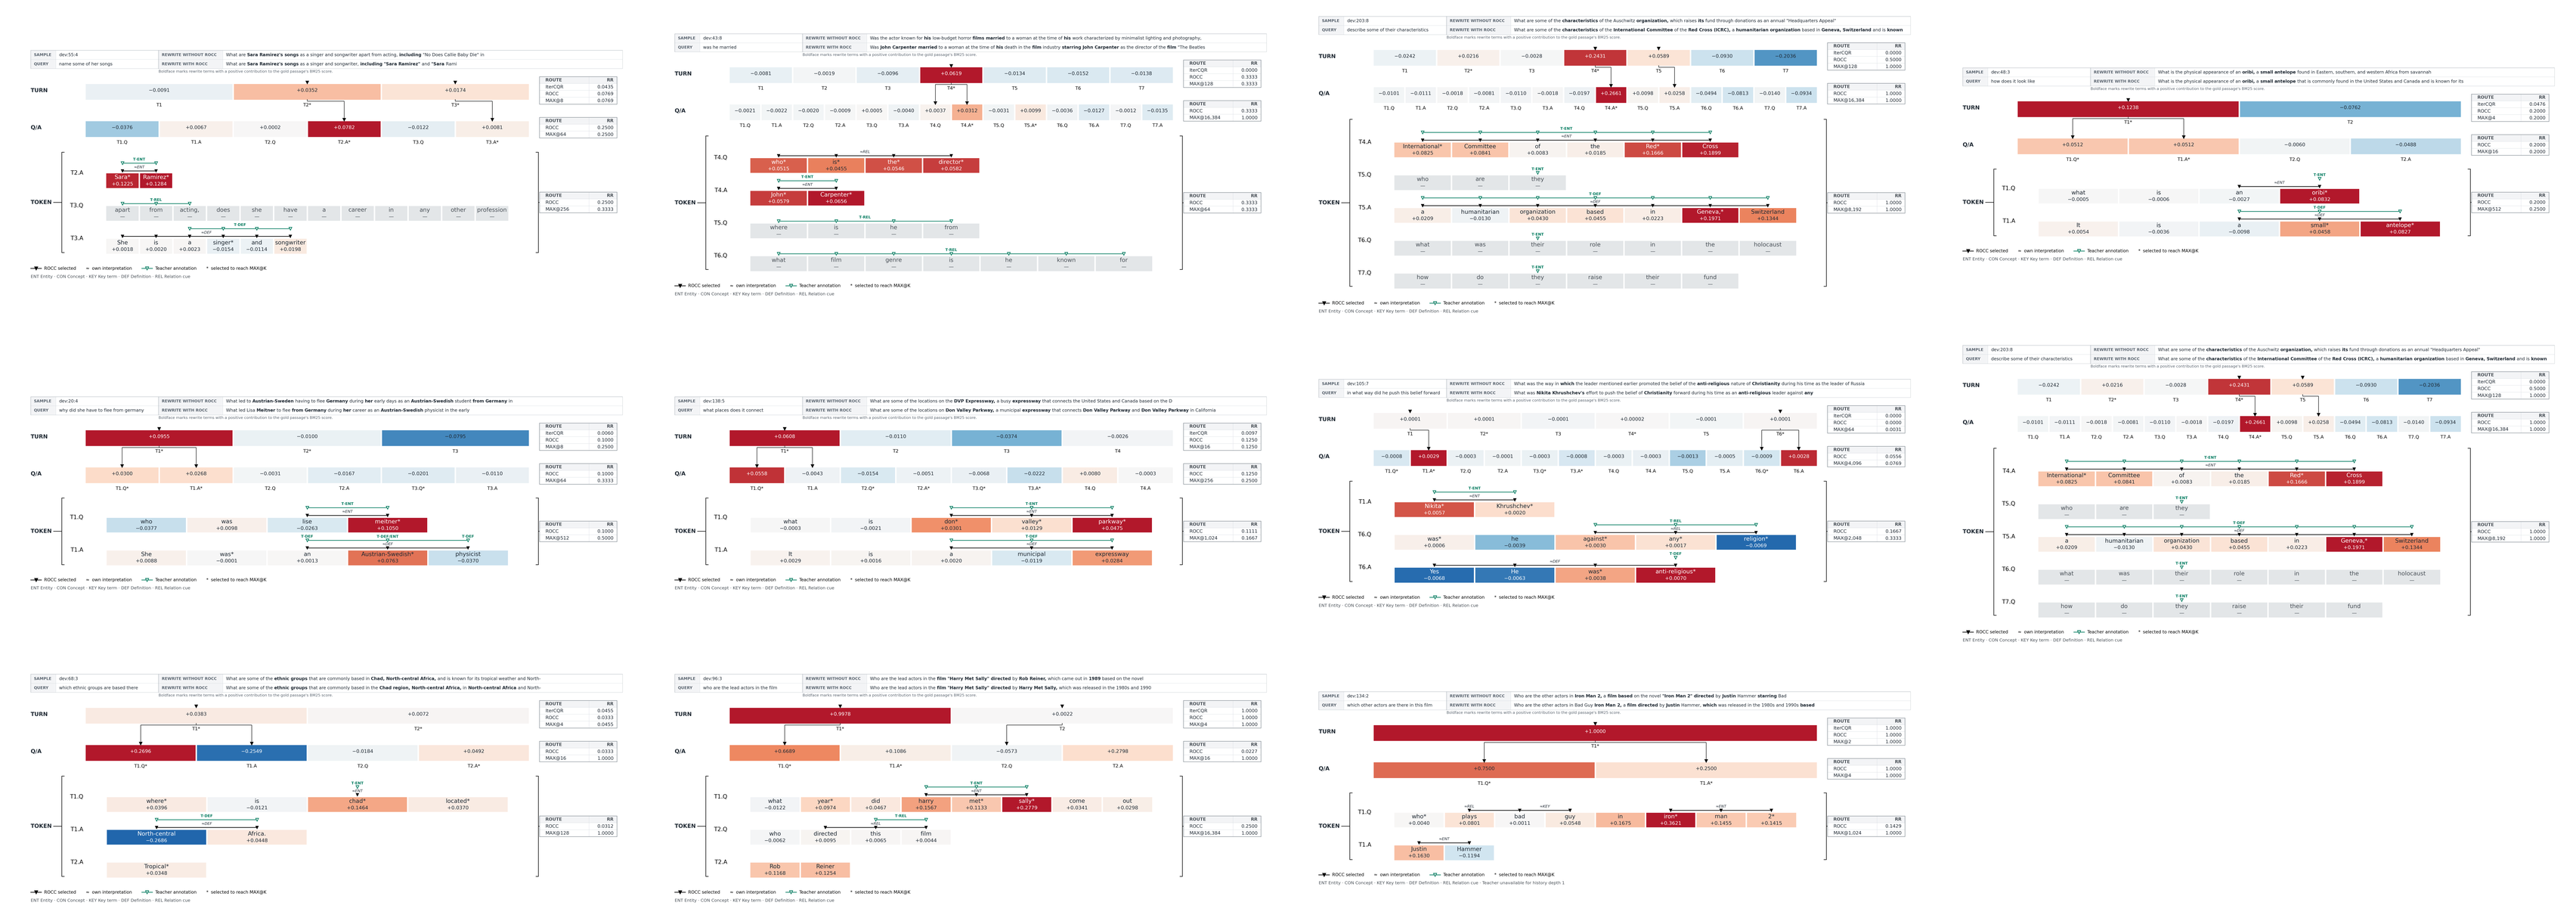

In [7]:
def build_overview(paths: Sequence[Path], output: Path, *, columns: int = 4) -> Path:
    target_width, padding = 820, 16
    thumbs = []
    for path in paths:
        with Image.open(path) as source:
            image = source.convert("RGB")
            height = round(image.height * target_width / image.width)
            thumbs.append(image.resize((target_width, height), Image.Resampling.LANCZOS))
    rows = [thumbs[index:index + columns] for index in range(0, len(thumbs), columns)]
    tile_width = target_width + 2 * padding
    row_heights = [max(image.height for image in row) + 2 * padding for row in rows]
    canvas = Image.new("RGB", (columns * tile_width, sum(row_heights)), "white")
    y0 = 0
    for row, row_height in zip(rows, row_heights, strict=True):
        max_height = row_height - 2 * padding
        for column, image in enumerate(row):
            x = column * tile_width + padding
            y = y0 + padding + (max_height - image.height) // 2
            canvas.paste(image, (x, y))
        y0 += row_height
    canvas.save(output)
    return output


bundle_pdf = FIGURE_DIR / "shap_hierarchy_all.pdf"
png_paths: list[Path] = []
pdf_paths: list[Path] = []
with PdfPages(bundle_pdf) as bundle:
    for stem, sample_id in PLOT_SPECS:
        outputs = render_hierarchy(
            games[sample_id],
            FIGURE_DIR / f"shap_hierarchy_{stem}",
            teacher_by_sample,
            POSTHOC_ANNOTATIONS,
            bm25_by_sample,
            pdf_pages=bundle,
        )
        png_paths.append(outputs["png"])
        pdf_paths.append(outputs["pdf"])

overview_path = build_overview(
    png_paths, FIGURE_DIR / "shap_hierarchy_overview.png"
)

assert len(png_paths) == len(pdf_paths) == len(PLOT_SPECS) == 11
assert all(path.is_file() and path.stat().st_size > 0 for path in [*png_paths, *pdf_paths, bundle_pdf, overview_path])
assert sha256_file(png_paths[2]) == sha256_file(png_paths[7])
with Image.open(overview_path) as overview:
    assert overview.size == (3408, 1214)

manifest = {
    "protocol": PROTOCOL,
    "input_fingerprint": input_fingerprint,
    "input_sha256": observed_hashes,
    "shap_version": shap.__version__,
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "matplotlib": importlib.metadata.version("matplotlib"),
        "pyserini": importlib.metadata.version("pyserini"),
        "pillow": importlib.metadata.version("pillow"),
    },
    "plot_order": [{"stem": stem, "sample_id": sample_id} for stem, sample_id in PLOT_SPECS],
    "outputs": {
        str(path.relative_to(RESULT_DIR)): sha256_file(path)
        for path in [
            *(game_path(sample_id) for sample_id in SAMPLE_IDS),
            *png_paths,
            *pdf_paths,
            bundle_pdf,
            overview_path,
            RESULT_DIR / "bm25_terms.json",
        ]
    },
}
atomic_json(RESULT_DIR / "manifest.json", manifest)

display(pd.DataFrame([{
    "pages": len(PLOT_SPECS),
    "unique_games": len(games),
    "bundle_pdf": str(bundle_pdf),
    "overview": str(overview_path),
    "manifest": str(RESULT_DIR / "manifest.json"),
}]))
display(DisplayImage(filename=str(overview_path)))

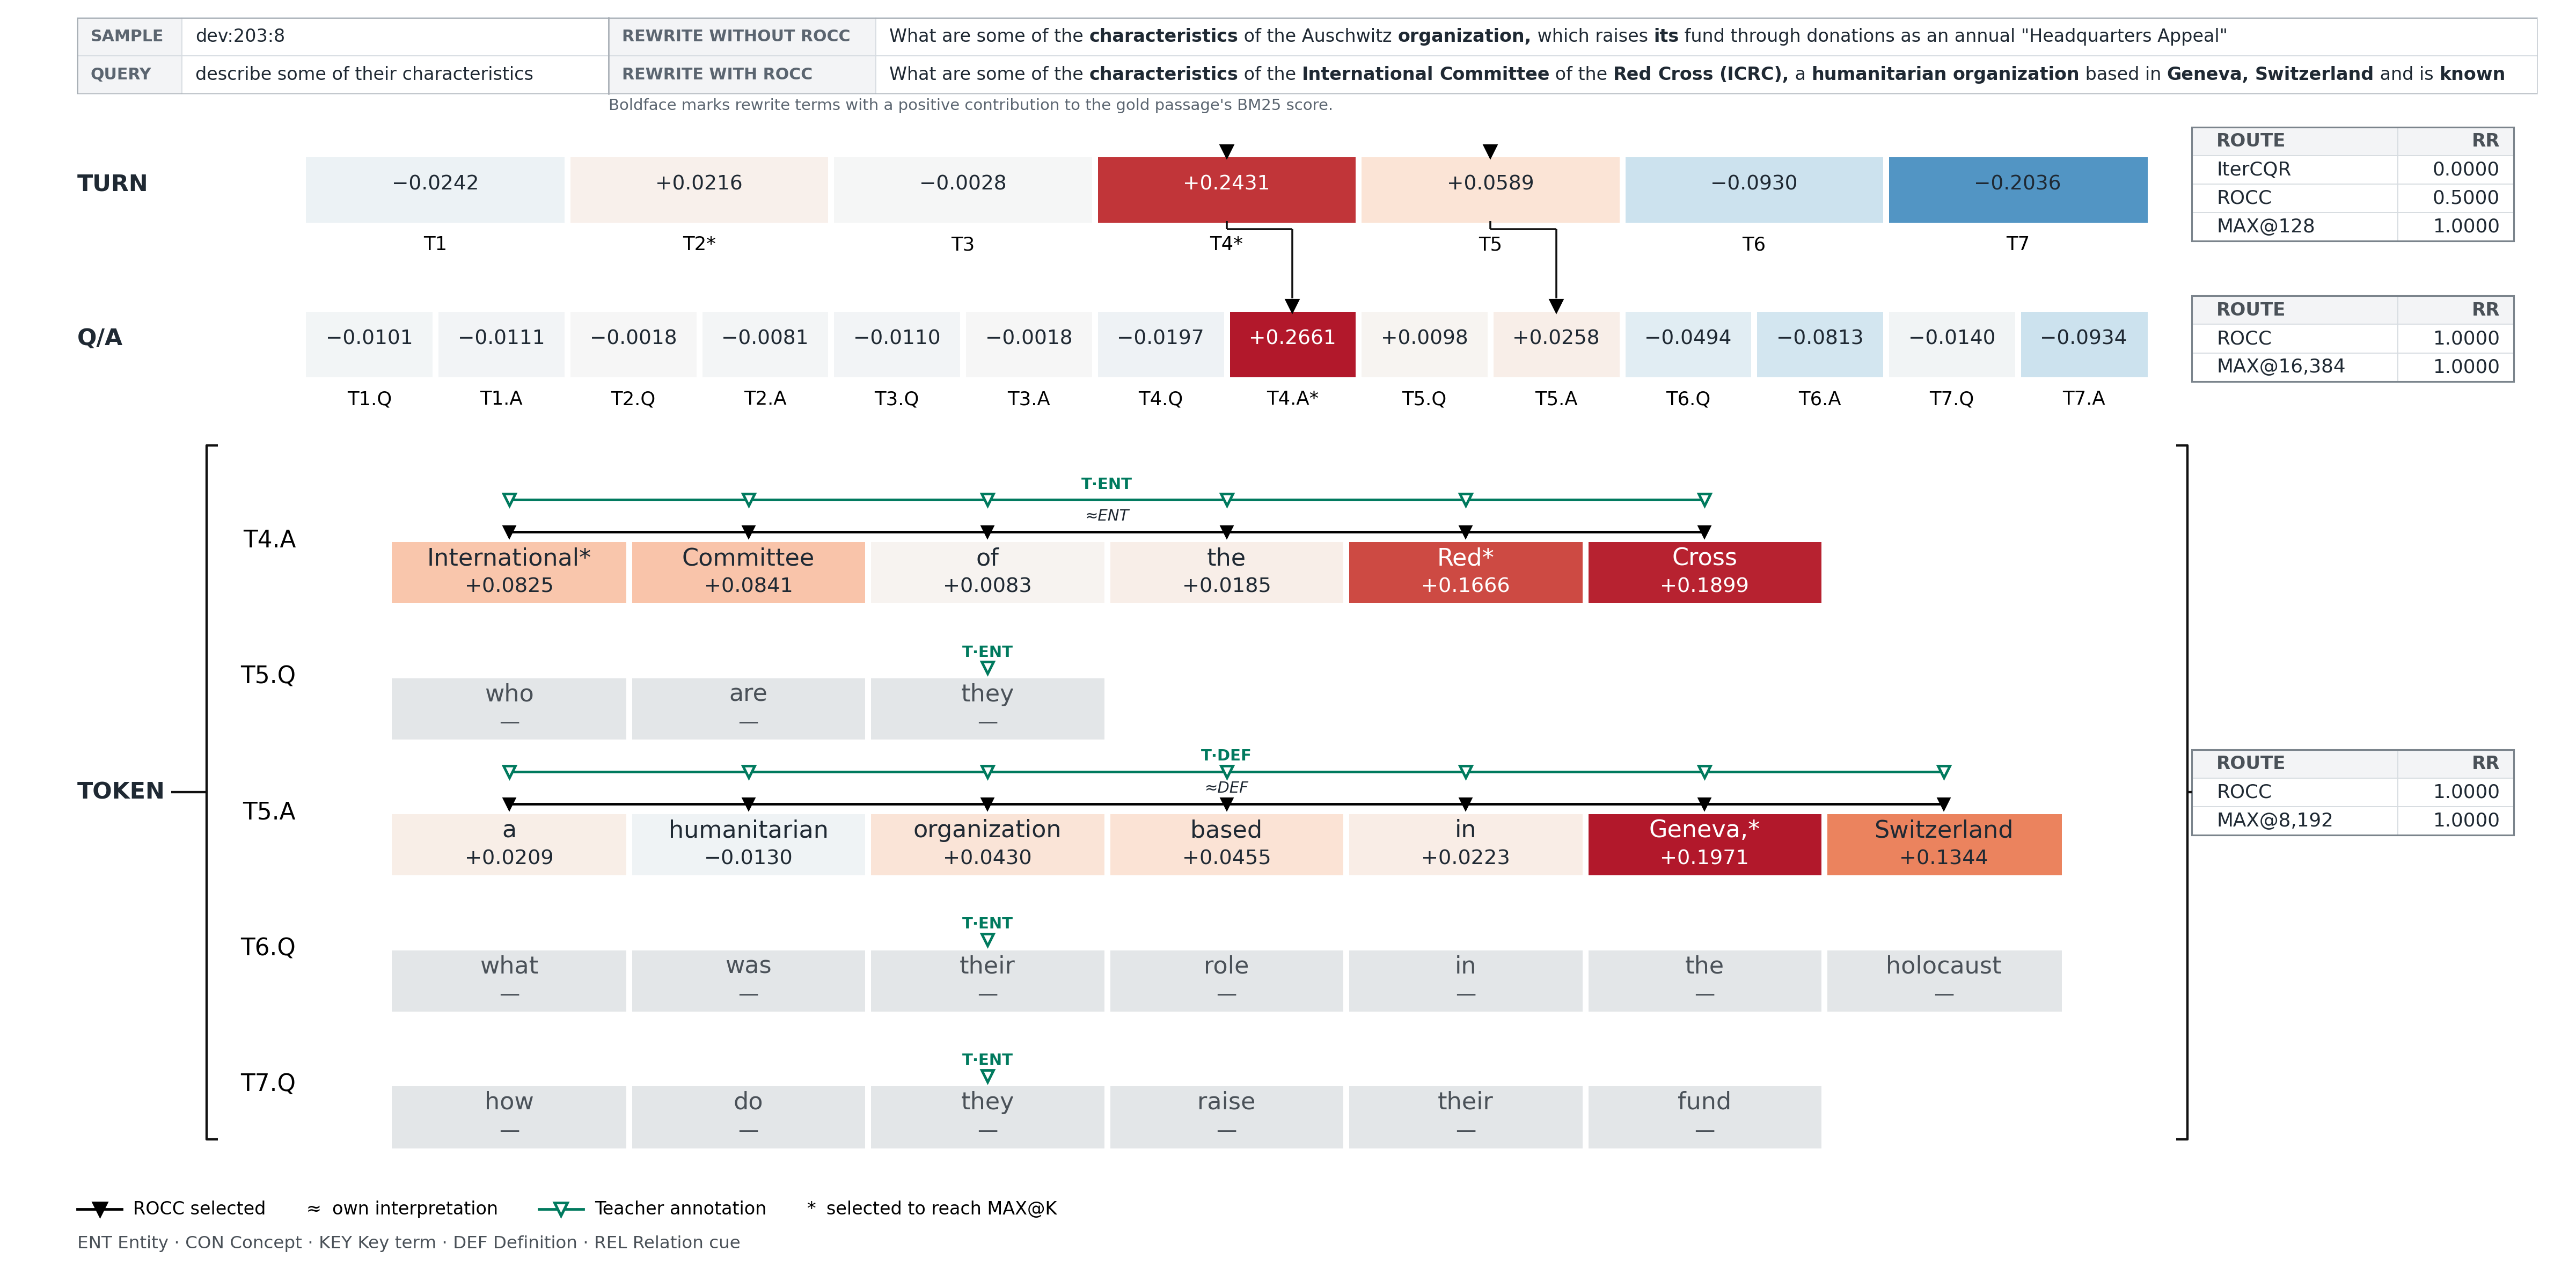

In [ ]:
DISPLAY_SAMPLE_ID = "dev:203:8"
DISPLAY_PLOT = FIGURE_DIR / "shap_hierarchy_dev203.png"

assert games[DISPLAY_SAMPLE_ID]["sample_id"] == DISPLAY_SAMPLE_ID
assert DISPLAY_PLOT.is_file()
display(DisplayImage(filename=str(DISPLAY_PLOT)))

The query “describe some of their characteristics” is turn 8 of TopiOCQA development conversation 203. Under the B64 limit, $I_{64}$ introduces the unrelated Auschwitz organization and misses the gold passage ($\mathrm{RR}=0$). With the larger input budget, $I_{512}$ ranks it second ($\mathrm{RR}=0.5$).

The base student $f_{\mathrm{base}}$ retains the complete answers $a_4$ (`T4.A`) and $a_5$ (`T5.A`). Their thirteen words produce a 30-token input, and $R_{64}$ retrieves the gold passage first ($\mathrm{RR}=1$). V2 projection adds no text because both answer fields are already complete. V1 projection also retains $q_4$ and $q_5$, which lowers reciprocal rank to 0.5.

In the word game, $v(\varnothing)=0$ and $v(\mathcal P)=1$. The largest positive values belong to “Geneva,” (+0.1971), “Cross” (+0.1899), and “Red” (+0.1666). Their values belong to this thirteen-word game. The separate games over all seven turns and fourteen fields both have $v(\varnothing)=v(\mathcal P)=0$, so their contributions sum to zero. Later turns have negative contributions. This case shows how the selected entity and definition support retrieval, without establishing that every retained word is necessary.

## Result summary

These tables read the saved results of this notebook and display them directly, without a separate export. Rerun the preceding experiment cells first when generating new results.


In [9]:
from experiments.scripts.analysis_results import display_results

display_results(PROJECT_ROOT / "experiments", '09_explainability')


**case**

,sample_id,previous_turns,selected_words
0,dev:203:8,7,13


**reciprocal rank**

,condition,RR,target_rank,rewriter_input_tokens
0,I512,0.5,2.0,209.0
1,I64,0.0,NaN,64.0
2,R64,1.0,1.0,30.0
3,"V1 projection, turns 4 and 5",0.5,2.0,NaN
4,"V2 projection, answer fields 4 and 5",1.0,1.0,NaN
5,R64 without humanitarian,1.0,1.0,NaN
6,R64 without based,0.5,2.0,NaN


**games**

...

,game,player,Shapley_value
0,turn,T1,-0.024159
1,turn,T2,0.021638
2,turn,T3,-0.002794
3,turn,T4,0.243106
4,turn,T5,0.058855
5,turn,T6,-0.093005
6,turn,T7,-0.203640
7,qa_all,T1.Q,-0.010096
8,qa_all,T1.A,-0.011134
9,qa_all,T2.Q,-0.001843


**word Shapley**

,player,Shapley_value
25,T4.A[0]:International,0.082528
26,T4.A[1]:Committee,0.084107
27,T4.A[2]:of,0.008302
28,T4.A[3]:the,0.018480
29,T4.A[4]:Red,0.166611
30,T4.A[5]:Cross,0.189911
31,T5.A[0]:a,0.020867
32,T5.A[1]:humanitarian,-0.013031
33,T5.A[2]:organization,0.042953
34,T5.A[3]:based,0.045511


**Auschwitz gold document BM25 weight**

,route,word,gold_document_BM25_weight
1,route_I,Auschwitz,0.0
